# Convolusional Neural Networks in Pytorch

This notebook implements a Convolutional Neural Network (CNN) in pytorch to classify images using the CIFAR10 dataset.

We first begin  by importing the necessary libraries. As well as setting our device to be the GPU.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

Next, we import the dataset, and use the provided function to split the data into training and test subsets. We additionally pass the transform.ToTensor() parameter as the data transform to convert the PIL images base format into Tensors.

In [3]:
data_base_path = "../data/cifar10_data/"

trainset = torchvision.datasets.CIFAR10(
    root=data_base_path,
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

testset = torchvision.datasets.CIFAR10(
    root=data_base_path,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

c:\GitHub\IntComp\notebooks\Local Notebooks\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


The final step of data preprocessing involves creating data loaders for both the train subset and test subset.

We also define our batch size to be 32.

In [4]:
batch_size = 32

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)

We now proceed to create the first CNN model.

Which consists of 3 convolution layers, each followed by a pooling layer, these convolution layers are of size 25, 50, and 75 filters respectively, all with a 3x3 kernel and padding of 1. After flattening, the output is passed through a fully connected layer of 512 neurons with dropout of 0.3, and finally to an output layer of 10 neurons corresponding to the 10 CIFAR-10 classes

In [5]:
IMG_CHANNELS = 3

model_1 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 8 x 8

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 4 x 4

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.3),
    nn.Linear(512, 10)
)

model_1 = model_1.to(device)

We now define an optimizer (Adam) and number of epochs (20).

In [6]:
optimizer_1 = Adam(model_1.parameters())

epochs = 20

For loss function, we use cross entropy as this is a classification problem.

In [7]:
loss_function = nn.CrossEntropyLoss()

In the next section we define our training function, alongside our custom accuracy function.

In [8]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test = X_test.to(device)
                y_test = y_test.to(device)
                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

Before creating our models, we define our testing function.

In [9]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device)
            y = y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## First CNN model

We train our first CNN model.

In [10]:
cnn_res_1 = train(model_1, train_loader, test_loader, loss_function, optimizer_1, epochs)

Training: 100%|██████████| 20/20 [06:45<00:00, 20.28s/epoch, test_acc=0.7426, test_loss=0.8971, train_acc=0.8755, train_loss=0.3449]


We can observe that it achieved a final test accuracy of 0.7426

In [11]:
test_loss_1, test_acc_1 = test(model_1, test_loader, loss_function)

print(f"Model 1 accuracy: {test_acc_1}")

Model 1 accuracy: 0.7425999999999996


Now is the time to define out plotting function to visualize the model's performance.

In [12]:
def plot_learning_curves_loss(train_losses, test_losses, train_acc, test_acc, _num_epochs):
    range_epochs = range(1, _num_epochs + 1)
    plt.plot(range_epochs, train_losses, label="Train Loss")
    plt.plot(range_epochs, test_losses, label="Test Loss")
    plt.plot(range_epochs, train_acc, label="Train Accuracy")
    plt.plot(range_epochs, test_acc, label="Test Accuracy")


    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.title("Learning Curves - Loss and Accuracy")
    plt.legend()
    plt.show()

Here we can observe how it is beginning to overfit as the test subset doesn't show significant improvement.

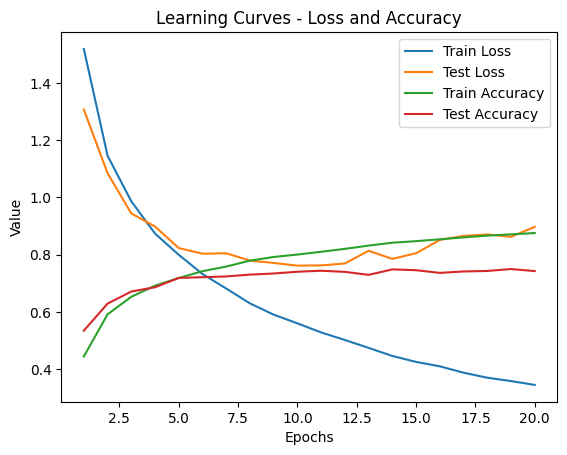

In [13]:
plot_learning_curves_loss(cnn_res_1['train_loss'], cnn_res_1['test_loss'], cnn_res_1['train_acc'], cnn_res_1['test_acc'], epochs)

## Second CNN model

Model 2 follows the same 3 convolution layer structure, but with smaller filters of size 15, 30, and 45. The classifier head is also extended with an extra fully connected layer (512 → 256 → 10) and slightly reduced dropout, making it a lighter but deeper model compared to Model 1.

Training: 100%|██████████| 20/20 [06:07<00:00, 18.37s/epoch, test_acc=0.7226, test_loss=0.8942, train_acc=0.8647, train_loss=0.3797]


Model 2 accuracy: 0.7225999999999986


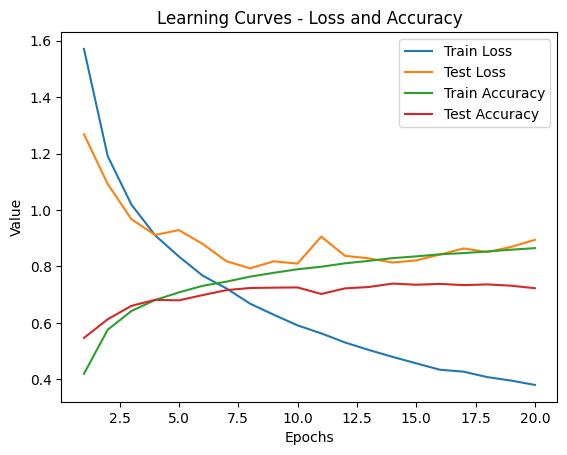

In [14]:
model_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 15, 3, stride=1, padding=1),  # 15 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 15 x 16 x 16

    nn.Conv2d(15, 30, 3, stride=1, padding=1),  # 30 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 30 x 8 x 8

    nn.Conv2d(30, 45, 3, stride=1, padding=1),  # 45 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 45 x 4 x 4

    nn.Flatten(),
    nn.Linear(45 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(.1),
    nn.Linear(256, 10)
)

model_2 = model_2.to(device)

optimizer_2 = Adam(model_2.parameters())

cnn_res_2 = train(model_2, train_loader, test_loader, loss_function, optimizer_2, epochs)

test_loss_2, test_acc_2 = test(model_2, test_loader, loss_function)

print(f"Model 2 accuracy: {test_acc_2}")

plot_learning_curves_loss(cnn_res_2['train_loss'], cnn_res_2['test_loss'], cnn_res_2['train_acc'], cnn_res_2['test_acc'], epochs)

Although having more complex fully connected layers, the less complex convolusional layers made it achieve a lower accuracy score, with 0.7226.

## Third CNN model

Model 3 uses filters of size 32, 64, and 128. It has the deepest classifier head of the three models, with three fully connected layers (512 → 256 → 256 → 10) and graduated dropout, giving it the most capacity overall.

Training: 100%|██████████| 20/20 [06:32<00:00, 19.63s/epoch, test_acc=0.7399, test_loss=0.9063, train_acc=0.9030, train_loss=0.2845]


Model 3 accuracy: 0.7398999999999997


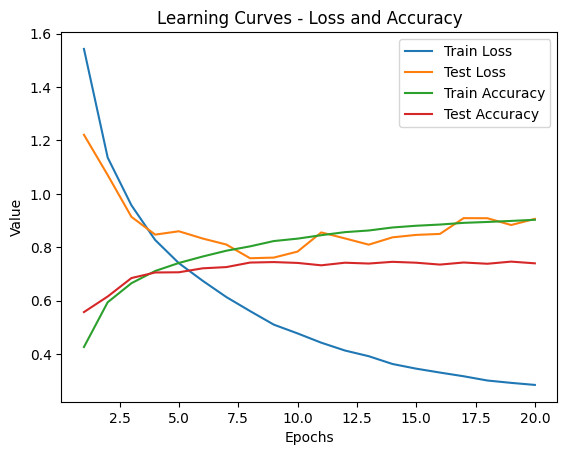

In [15]:
model_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 32 x 16 x 16

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 64 x 8 x 8

    nn.Conv2d(64, 128, 3, stride=1, padding=1),  # 128 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 128 x 4 x 4

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(.1),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Dropout(.1),
    nn.Linear(256, 10)
)

model_3 = model_3.to(device)

optimizer_3 = Adam(model_3.parameters())

cnn_res_3 = train(model_3, train_loader, test_loader, loss_function, optimizer_3, epochs)

test_loss_3, test_acc_3 = test(model_3, test_loader, loss_function)

print(f"Model 3 accuracy: {test_acc_3}")

plot_learning_curves_loss(cnn_res_3['train_loss'], cnn_res_3['test_loss'], cnn_res_3['train_acc'], cnn_res_3['test_acc'], epochs)

Although having a more complete and capable model, we ended up with a slightly lower accuracy score on the test subset than the first original model, with a value of 0.7399.

#### Model Comparison

As as final step, we compare the three models.

In [17]:
print(f"Model 1 accuracy: {test_acc_1:.4f}")
print(f"Model 2 accuracy: {test_acc_2:.4f}")
print(f"Model 3 accuracy: {test_acc_3:.4f}")

Model 1 accuracy: 0.7426
Model 2 accuracy: 0.7226
Model 3 accuracy: 0.7399


As stated before, the best performing model of them all was the first one.

#### Conclusion

As a conclusion, Convolusional Neural Networks are a great machine learning tool to learn complex patterns from structured data, such as images. Pytorch offers easy tools to create neural networks such as the ones implemented in this notebook.

Although we did not achieve a stellar result, additional hyperparameter and model arquitecture tweaking may offer better results, specifically on the testing dataset as that is the one that matters when a model is exported to a production environment.

As seen in the code cells and results, CNNs aren't hard to implement, and offer greater efficiency than traditional DNN models, with the advantage of using less parameters because of the pooling layers, which dramatically reduces the computational power needed and memory to train models.